In [1]:
# ============================================================
# LANGKAH 1: Import Library & Setup
# ============================================================
import sys
import os
import time
import json
import pandas as pd
import numpy as np
from datetime import datetime

# Tambahkan parent folder ke path agar bisa import module Multi Agent
sys.path.insert(0, os.path.abspath('..'))

from agents.dialogue_agent import run_pesanan
from agents.critic_agent import run as critic_run
from config import CRITIC_THRESHOLD

print("Semua library berhasil diimport!")
print(f"CRITIC_THRESHOLD: {CRITIC_THRESHOLD}")
print(f"Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

Semua library berhasil diimport!
CRITIC_THRESHOLD: 4.0
Timestamp: 2026-09-04 11:54:29


In [2]:
# ============================================================
# LANGKAH 2: Definisikan Profil NPC & Dialog Awal (BAD)
# ============================================================
# Profil Raka — dari eksperimen critic consistency
# Dialog awal: dialog BAD yang akan diperbaiki lewat loop actor-critic

PROFILE = {
    "nama": "Raka",
    "usia": "remaja",
    "gender": "pria",
    "ocean": {
        "openness": 62,
        "conscientiousness": 55,
        "extraversion": 78,
        "agreeableness": 35,
        "neuroticism": 72,
    },
    "background": (
        "Mahasiswa teknik yang hobi main gitar di kosan. "
        "Tipikal orang yang keliatan cuek tapi sebenernya perhatian."
    ),
    "masalah_hari_ini": (
        "Deadline tugas kelompok dimajukan jadi besok padahal anggota timnya "
        "pada menghilang semua."
    ),
    "minuman_dipesan": "Green Tea",
}

# Dialog BAD — diambil dari hasil eksperimen critic consistency
DIALOG_AWAL = "Saya mau memesan green tea, cepat ya, saya sedang buru-buru."

print("Profil NPC:")
print(f"  Nama     : {PROFILE['nama']}")
print(f"  Usia     : {PROFILE['usia']}")
print(f"  Gender   : {PROFILE['gender']}")
print(f"  OCEAN    : {PROFILE['ocean']}")
print(f"  Minuman  : {PROFILE['minuman_dipesan']}")
print(f"\nDialog awal (BAD):")
print(f"  \"{DIALOG_AWAL}\"")

Profil NPC:
  Nama     : Raka
  Usia     : remaja
  Gender   : pria
  OCEAN    : {'openness': 62, 'conscientiousness': 55, 'extraversion': 78, 'agreeableness': 35, 'neuroticism': 72}
  Minuman  : Green Tea

Dialog awal (BAD):
  "Saya mau memesan green tea, cepat ya, saya sedang buru-buru."


In [3]:
# ============================================================
# LANGKAH 3: Jalankan Actor-Critic Loop (10 Iterasi)
# ============================================================
# Alur per iterasi:
#   1. Kirim dialog ke Critic Agent → dapat skor + saran
#   2. Kirim saran ke Dialogue Agent → dapat dialog revisi
#   3. Ulangi dengan dialog revisi sebagai input berikutnya
#
# Diukur: waktu per iterasi, skor critic, dan dialog hasil revisi

MAX_LOOP = 10
hasil_loop = []

# State dasar — digunakan sebagai basis untuk critic & dialogue
state_base = {
    "nama": PROFILE["nama"],
    "usia": PROFILE["usia"],
    "gender": PROFILE["gender"],
    "ocean": PROFILE["ocean"],
    "background": PROFILE["background"],
    "masalah_hari_ini": PROFILE["masalah_hari_ini"],
    "minuman_dipesan": PROFILE["minuman_dipesan"],
    "konteks_critic": "pesanan",
    "revisi_ke": 0,
    "mood": 50,
}

dialog_sekarang = DIALOG_AWAL
saran_sebelumnya = ""

print(f"{'='*80}")
print(f"MEMULAI ACTOR-CRITIC LOOP — {MAX_LOOP} iterasi")
print(f"{'='*80}")
print(f"Dialog awal: \"{dialog_sekarang}\"")
print()

for i in range(1, MAX_LOOP + 1):
    t_start = time.perf_counter()
    
    # ── STEP 1: CRITIC — evaluasi dialog sekarang ──
    state_critic = {**state_base, "dialog_pesanan": dialog_sekarang}
    critic_result = critic_run(state_critic)
    
    skor = critic_result.get("critic_skor", 0)
    skor_dimensi = critic_result.get("critic_skor_dimensi", {})
    lulus = skor >= CRITIC_THRESHOLD
    saran = critic_result.get("critic_saran", "")
    justifikasi = critic_result.get("critic_justifikasi", "")
    
    # ── STEP 2: DIALOGUE — revisi berdasarkan saran critic ──
    state_dialogue = {
        **state_base,
        "dialog_pesanan": dialog_sekarang,
        "revisi_ke": i,
    }
    dialogue_result = run_pesanan(state_dialogue, saran_revisi=saran)
    dialog_baru = dialogue_result.get("dialog_pesanan", dialog_sekarang)
    
    t_end = time.perf_counter()
    waktu_iterasi = round(t_end - t_start, 3)
    
    # Cek apakah dialog berubah dari sebelumnya
    berubah = (dialog_baru.strip() != dialog_sekarang.strip())
    
    # Simpan hasil
    hasil_loop.append({
        "iterasi": i,
        "skor_critic": round(skor, 3),
        "lulus_threshold": lulus,
        "dialog_sebelum": dialog_sekarang,
        "dialog_sesudah": dialog_baru,
        "dialog_berubah": berubah,
        "saran_critic": saran,
        "justifikasi_critic": justifikasi,
        "waktu_iterasi_detik": waktu_iterasi,
        "skor_dimensi": skor_dimensi,
    })
    
    print(f"--- Iterasi {i} ---")
    print(f"  Skor Critic : {skor:.3f} {'✅ LULUS' if lulus else '❌ GAGAL'} (threshold={CRITIC_THRESHOLD})")
    print(f"  Waktu       : {waktu_iterasi}s")
    print(f"  Dialog baru : \"{dialog_baru[:120]}{'...' if len(dialog_baru)>120 else ''}\"")
    print(f"  Berubah?    : {'YA' if berubah else 'TIDAK (konstan)'}")
    print()
    
    # Update dialog untuk iterasi berikutnya
    dialog_sekarang = dialog_baru
    saran_sebelumnya = saran

print(f"{'='*80}")
print(f"✅ Actor-Critic Loop selesai — {MAX_LOOP} iterasi")
print(f"{'='*80}")

MEMULAI ACTOR-CRITIC LOOP — 10 iterasi
Dialog awal: "Saya mau memesan green tea, cepat ya, saya sedang buru-buru."

  [LLM INFO] Model 'GPT-5.6-sol' adalah reasoning model — parameter sampling (temperature/frequency_penalty/presence_penalty) di-skip.
  [LLM INFO] Model 'GPT-5.6-luna' adalah reasoning model — parameter sampling (temperature/frequency_penalty/presence_penalty) di-skip.
--- Iterasi 1 ---
  Skor Critic : 3.500 ❌ GAGAL (threshold=4.0)
  Waktu       : 12.804s
  Dialog baru : "Eh, kak, Green Tea satu, dong. Kalau bisa agak cepetan, ya—aku lagi buru-buru banget, takut keburu makin kacau. Gulanya ..."
  Berubah?    : YA

  [LLM INFO] Model 'GPT-5.6-sol' adalah reasoning model — parameter sampling (temperature/frequency_penalty/presence_penalty) di-skip.
  [LLM INFO] Model 'GPT-5.6-luna' adalah reasoning model — parameter sampling (temperature/frequency_penalty/presence_penalty) di-skip.
--- Iterasi 2 ---
  Skor Critic : 4.625 ✅ LULUS (threshold=4.0)
  Waktu       : 10.104s
  Di

In [4]:
# ============================================================
# LANGKAH 4: Buat DataFrame & Tampilkan Ringkasan
# ============================================================
df = pd.DataFrame(hasil_loop)

# Ekstrak skor per dimensi ke kolom terpisah
for dim in ["interesting", "engaging", "specific", "relevant",
            "correct", "semantically_appropriate", "understandable", "fluent"]:
    df[f"dim_{dim}"] = df["skor_dimensi"].apply(lambda d, k=dim: d.get(k, 0) if isinstance(d, dict) else 0)

# Kolom ringkasan (tanpa teks panjang)
kolom_ringkas = [
    "iterasi", "skor_critic", "lulus_threshold", "dialog_berubah",
    "waktu_iterasi_detik",
    "dim_interesting", "dim_engaging", "dim_specific", "dim_relevant",
    "dim_correct", "dim_semantically_appropriate", "dim_understandable", "dim_fluent",
]

print(f"Total iterasi: {len(df)}")
print(f"Kolom: {list(df.columns)}")
print(f"\nRingkasan hasil actor-critic loop:")
df[kolom_ringkas]

Total iterasi: 10
Kolom: ['iterasi', 'skor_critic', 'lulus_threshold', 'dialog_sebelum', 'dialog_sesudah', 'dialog_berubah', 'saran_critic', 'justifikasi_critic', 'waktu_iterasi_detik', 'skor_dimensi', 'dim_interesting', 'dim_engaging', 'dim_specific', 'dim_relevant', 'dim_correct', 'dim_semantically_appropriate', 'dim_understandable', 'dim_fluent']

Ringkasan hasil actor-critic loop:


,iterasi,skor_critic,lulus_threshold,dialog_berubah,waktu_iterasi_detik,dim_interesting,dim_engaging,dim_specific,dim_relevant,dim_correct,dim_semantically_appropriate,dim_understandable,dim_fluent
0,1,3.500,False,True,12.804,2,2,3,5,2,5,5,4
1,2,4.625,True,True,10.104,4,4,5,5,4,5,5,5
2,3,4.250,True,True,10.682,3,4,4,5,3,5,5,5
3,4,4.250,True,True,12.225,4,3,4,5,3,5,5,5
4,5,4.250,True,True,9.177,4,3,4,5,3,5,5,5
5,6,3.875,False,True,14.974,3,3,3,5,2,5,5,5
6,7,4.875,True,True,8.845,5,4,5,5,5,5,5,5
7,8,4.500,True,True,10.900,4,4,5,5,3,5,5,5
8,9,4.125,True,True,12.678,3,3,4,5,3,5,5,5
9,10,4.375,True,True,12.060,4,4,4,5,3,5,5,5


In [5]:
# ============================================================
# LANGKAH 5: Analisis Konvergensi — Kapan Dialog Berhenti Berubah?
# ============================================================
# Deteksi: iterasi pertama di mana dialog TIDAK berubah (konstan)
# Ini menjadi indikator bahwa revisi sudah mencapai titik jenuh

print("=" * 70)
print("ANALISIS KONVERGENSI DIALOG")
print("=" * 70)

# Cari iterasi pertama di mana dialog berhenti berubah
konstan_mulai = None
for i, row in df.iterrows():
    if not row["dialog_berubah"]:
        konstan_mulai = row["iterasi"]
        print(f"✅ Dialog mulai KONSTAN pada iterasi ke-{konstan_mulai}")
        break

if konstan_mulai is None:
    print("⚠️ Dialog masih berubah sampai iterasi terakhir (belum konstan)")

# Cari iterasi pertama yang LULUS threshold
lulus_mulai = None
for i, row in df.iterrows():
    if row["lulus_threshold"]:
        lulus_mulai = row["iterasi"]
        print(f"✅ Dialog pertama kali LULUS threshold pada iterasi ke-{lulus_mulai}")
        break

if lulus_mulai is None:
    print("⚠️ Dialog TIDAK PERNAH lulus threshold dalam 10 iterasi")

# Statistik perubahan
total_berubah = df["dialog_berubah"].sum()
total_tidak = len(df) - total_berubah
print(f"\nTotal iterasi dengan dialog BERUBAH  : {total_berubah}")
print(f"Total iterasi dengan dialog KONSTAN  : {total_tidak}")
print(f"Persentase konstan                   : {total_tidak/len(df)*100:.1f}%")

# Rekomendasi MAX_REVISI
print(f"\n{'='*70}")
print("REKOMENDASI UNTUK SISTEM")
print(f"{'='*70}")
if konstan_mulai:
    print(f"Dialog sudah konstan di iterasi ke-{konstan_mulai}")
    print(f"→ Rekomendasi MAX_REVISI = {konstan_mulai} kali (saat ini: 2)")
elif lulus_mulai:
    print(f"Dialog lulus di iterasi ke-{lulus_mulai}, tapi masih berubah")
    print(f"→ Rekomendasi MAX_REVISI = {lulus_mulai + 1} kali")
else:
    print("Dialog belum lulus & belum konstan dalam 10 iterasi")
    print("→ Perlu investigasi lebih lanjut")

print(f"\nNilai MAX_REVISI saat ini di sistem: 2")

ANALISIS KONVERGENSI DIALOG
⚠️ Dialog masih berubah sampai iterasi terakhir (belum konstan)
✅ Dialog pertama kali LULUS threshold pada iterasi ke-2

Total iterasi dengan dialog BERUBAH  : 10
Total iterasi dengan dialog KONSTAN  : 0
Persentase konstan                   : 0.0%

REKOMENDASI UNTUK SISTEM
Dialog lulus di iterasi ke-2, tapi masih berubah
→ Rekomendasi MAX_REVISI = 3 kali

Nilai MAX_REVISI saat ini di sistem: 2


In [6]:
# ============================================================
# LANGKAH 6: Evolusi Dialog — Perbandingan per Iterasi
# ============================================================
# Tampilkan dialog sebelum & sesudah setiap iterasi untuk
# melihat bagaimana dialog berevolusi sepanjang loop

print("=" * 70)
print("EVOLUSI DIALOG PER ITERASI")
print("=" * 70)

for i, row in df.iterrows():
    print(f"\n--- Iterasi {row['iterasi']} (skor={row['skor_critic']:.3f}, "
          f"{'LULUS' if row['lulus_threshold'] else 'GAGAL'}, "
          f"{'BERUBAH' if row['dialog_berubah'] else 'KONSTAN'}) ---")
    print(f"  SEBELUM: \"{row['dialog_sebelum']}\"")
    print(f"  SESUDAH: \"{row['dialog_sesudah']}\"")
    if row['dialog_berubah']:
        print(f"  SARAN  : \"{row['saran_critic'][:200]}{'...' if len(str(row['saran_critic']))>200 else ''}\"")

EVOLUSI DIALOG PER ITERASI

--- Iterasi 1 (skor=3.500, GAGAL, BERUBAH) ---
  SEBELUM: "Saya mau memesan green tea, cepat ya, saya sedang buru-buru."
  SESUDAH: "Eh, kak, Green Tea satu, dong. Kalau bisa agak cepetan, ya—aku lagi buru-buru banget, takut keburu makin kacau. Gulanya jangan kebanyakan, aku nggak kuat yang kemanisan."
  SARAN  : "Gunakan sapaan 'kak', partikel gaul, interjeksi, dan detail alasan terburu-buru agar kepribadian Raka lebih terlihat. Contoh: "Eh, Kak, aku pesan Green Tea satu, dong. Tolong agak cepetan, ya—aku lagi..."

--- Iterasi 2 (skor=4.625, LULUS, BERUBAH) ---
  SEBELUM: "Eh, kak, Green Tea satu, dong. Kalau bisa agak cepetan, ya—aku lagi buru-buru banget, takut keburu makin kacau. Gulanya jangan kebanyakan, aku nggak kuat yang kemanisan."
  SESUDAH: "Kak, Green Tea satu, ya. Yang dingin aja... kepala gue lagi panas banget gara-gara urusan tugas."
  SARAN  : ""

--- Iterasi 3 (skor=4.250, LULUS, BERUBAH) ---
  SEBELUM: "Kak, Green Tea satu, ya. Yang dingin

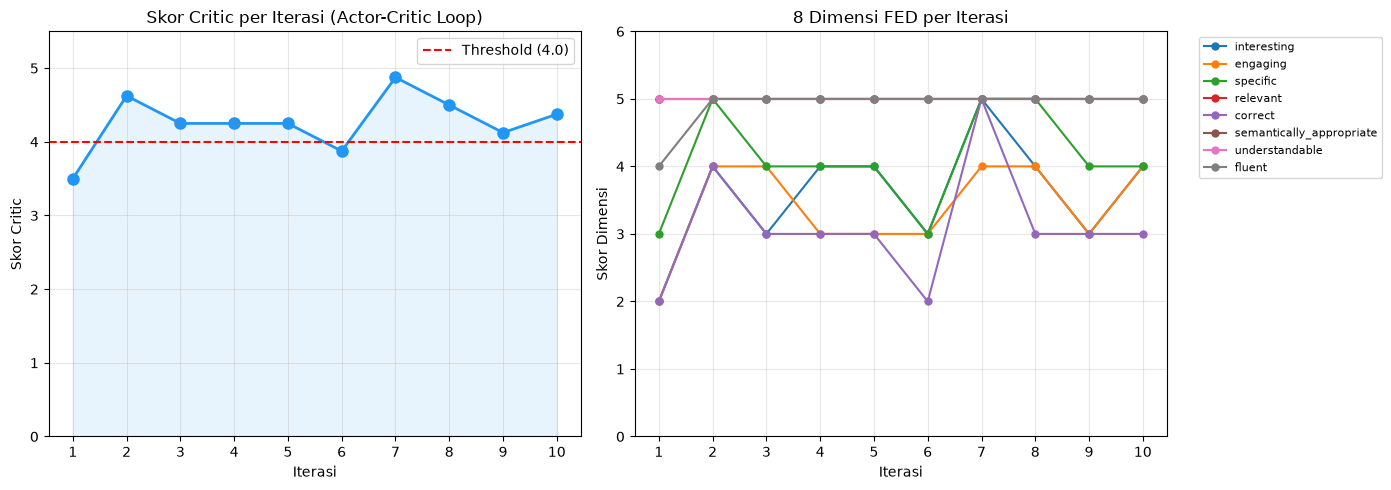

In [7]:
# ============================================================
# LANGKAH 7: Visualisasi Skor Critic per Iterasi
# ============================================================
# Plot skor critic vs iterasi untuk melihat tren perbaikan

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Skor total per iterasi
ax1 = axes[0]
ax1.plot(df["iterasi"], df["skor_critic"], marker="o", linewidth=2, markersize=8, color="#2196F3")
ax1.axhline(y=CRITIC_THRESHOLD, color="red", linestyle="--", linewidth=1.5, label=f"Threshold ({CRITIC_THRESHOLD})")
ax1.fill_between(df["iterasi"], 0, df["skor_critic"], alpha=0.1, color="#2196F3")
ax1.set_xlabel("Iterasi")
ax1.set_ylabel("Skor Critic")
ax1.set_title("Skor Critic per Iterasi (Actor-Critic Loop)")
ax1.set_ylim(0, 5.5)
ax1.set_xticks(range(1, MAX_LOOP + 1))
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: 8 dimensi FED per iterasi
ax2 = axes[1]
dim_cols = [c for c in df.columns if c.startswith("dim_")]
dim_labels = [c.replace("dim_", "") for c in dim_cols]

for j, col in enumerate(dim_cols):
    ax2.plot(df["iterasi"], df[col], marker="o", linewidth=1.5, markersize=5, label=dim_labels[j])

ax2.set_xlabel("Iterasi")
ax2.set_ylabel("Skor Dimensi")
ax2.set_title("8 Dimensi FED per Iterasi")
ax2.set_ylim(0, 6)
ax2.set_xticks(range(1, MAX_LOOP + 1))
ax2.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
# ============================================================
# LANGKAH 8: Simpan Hasil ke CSV
# ============================================================
output_path = "hasil_actor_critic_loop.csv"

# Simpan versi ringkas (tanpa teks panjang & dict)
kolom_simpan = [c for c in df.columns if c not in ["dialog_sebelum", "dialog_sesudah",
                                                     "saran_critic", "justifikasi_critic",
                                                     "skor_dimensi"]]
df_simpan = df[kolom_simpan].copy()
df_simpan.to_csv(output_path, index=False, encoding="utf-8")

print(f"✅ Hasil ringkas disimpan ke: {output_path}")
print(f"   Jumlah iterasi: {len(df_simpan)}")
print(f"   Jumlah kolom  : {len(df_simpan.columns)}")

# Juga simpan versi lengkap dengan dialog text
output_full = "hasil_actor_critic_loop_full.csv"
kolom_full = [c for c in df.columns if c not in ["skor_dimensi"]]
df[kolom_full].to_csv(output_full, index=False, encoding="utf-8")
print(f"✅ Hasil lengkap disimpan ke: {output_full}")

print(f"\nStatistik global:")
print(f"   Skor awal (iterasi 1)  : {df['skor_critic'].iloc[0]:.3f}")
print(f"   Skor akhir (iterasi {MAX_LOOP}) : {df['skor_critic'].iloc[-1]:.3f}")
print(f"   Peningkatan skor       : {df['skor_critic'].iloc[-1] - df['skor_critic'].iloc[0]:.3f}")
print(f"   Rata-rata waktu/iterasi: {df['waktu_iterasi_detik'].mean():.3f} detik")
print(f"   Total waktu loop       : {df['waktu_iterasi_detik'].sum():.3f} detik")
print(f"   Iterasi sampai lulus   : {df[df['lulus_threshold']]['iterasi'].min() if df['lulus_threshold'].any() else 'TIDAK LULUS'}")
print(f"   Iterasi sampai konstan : {df[~df['dialog_berubah']]['iterasi'].min() if not df['dialog_berubah'].all() else 'TIDAK KONSTAN'}")

✅ Hasil ringkas disimpan ke: hasil_actor_critic_loop.csv
   Jumlah iterasi: 10
   Jumlah kolom  : 13
✅ Hasil lengkap disimpan ke: hasil_actor_critic_loop_full.csv

Statistik global:
   Skor awal (iterasi 1)  : 3.500
   Skor akhir (iterasi 10) : 4.375
   Peningkatan skor       : 0.875
   Rata-rata waktu/iterasi: 11.445 detik
   Total waktu loop       : 114.449 detik
   Iterasi sampai lulus   : 2
   Iterasi sampai konstan : TIDAK KONSTAN
